### **1. Pendahuluan**
Setelah melakukan eksplorasi data (EDA) pada notebook sebelumnya, tahap ini berfokus pada mempersiapkan dataset agar optimal untuk proses pemodelan machine learning. Kita akan mengubah data mentah yang sudah bersih menjadi fitur-fitur yang memiliki daya prediksi tinggi berdasarkan **3 Pilar Logistik (Waktu, Jarak, Administrasi)**.

### **2. Penggunaan utils.py (Modular Programming)**
Berbeda dengan notebook sebelumnya, mulai tahap ini kita menggunakan file `utils.py`.
* **Tujuan**: Menyimpan fungsi-fungsi *reusable* (seperti loading data dan pengecekan kualitas) agar kode di notebook ini tetap ringkas dan mudah dibaca.
* **Cara Pakai**: Menggunakan perintah `%autoreload` agar setiap perubahan di file `.py` langsung terdeteksi tanpa restart kernel.

### **3. Langkah-langkah & Tujuan**
Tahapan utama dalam notebook ini berfokus pada **Data Preparation** sebelum masuk ke fase teknis pemodelan:

1.  **Feature Engineering (Konstruksi Fitur)**:
    * **Pilar Waktu**: Mengekstrak `month` dan `day_of_week` untuk menangkap efek *seasonal*.
    * **Pilar Jarak**: Membuat fitur `is_sp_district` untuk membedakan kapasitas logistik antar wilayah.
    * **Target Label**: Mengonstruksi variabel target `is_late` dan variabel kontrol `delivery_time`.

2.  **Outlier Analysis & Handling**: Melakukan inspeksi statistik dan visual (Boxplot/Histogram) untuk membersihkan data pengiriman yang tidak logis (ekstrem > 60 hari).

3.  **Data Integrity Check**: Memastikan tidak ada nilai kosong (*missing values*) yang tersisa pada fitur-fitur krusial setelah proses penggabungan.

4.  **Final Export**: Menyimpan Master Dataset yang sudah bersih dan kaya fitur ke folder `data/processed/` dalam format `.pkl`.

### 1. Setup & Import
Kita panggil fungsi yang sudah ada di utils.py agar tidak perlu menulisnya lagi.

In [1]:
import sys
import os
import pandas as pd
import numpy as np

# 1. Daftarkan folder src
src_path = os.path.abspath(os.path.join('..', 'src'))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

%reload_ext autoreload
%autoreload 2

# 2. Import fungsi dari utils.py
from utils import load_all_data

print("--- Memulai Proses Load Data ---")

# 3. Jalankan fungsi load_all_data
# Pastikan folder data/raw sudah ada isinya ya!
orders, payments, customers = load_all_data(base_path="../data/raw/")

# 4. CEK INFO DATA 
print("\n--- Ringkasan Data yang Berhasil Dimuat ---")

datasets = {
    "Orders": orders,
    "Payments": payments,
    "Customers": customers
}

for name, df in datasets.items():
    print(f"\n[Dataset {name}]")
    print(f"- Jumlah Baris: {df.shape[0]}")
    print(f"- Jumlah Kolom: {df.shape[1]}")
    print(f"- Kolom: {list(df.columns)}")
    # Cek apakah ada data yang kosong (Null)
    missing = df.isnull().sum().sum()
    print(f"- Total Missing Values: {missing}")

print("\nSemua data sudah siap digunakan!")

--- Memulai Proses Load Data ---

--- Ringkasan Data yang Berhasil Dimuat ---

[Dataset Orders]
- Jumlah Baris: 99441
- Jumlah Kolom: 8
- Kolom: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
- Total Missing Values: 4908

[Dataset Payments]
- Jumlah Baris: 103886
- Jumlah Kolom: 5
- Kolom: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
- Total Missing Values: 0

[Dataset Customers]
- Jumlah Baris: 99441
- Jumlah Kolom: 5
- Kolom: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
- Total Missing Values: 0

Semua data sudah siap digunakan!


### 2: Memuat dan Menggabungkan Data

In [2]:
import sys
import os

# 1. Daftarkan folder src
src_path = os.path.abspath(os.path.join('..', 'src'))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# 2. Aktifkan reload otomatis (PENTING: agar perubahan di utils terbaca)
%reload_ext autoreload
%autoreload 2

# 3. Import fungsi yang dibutuhkan
from utils import load_and_merge_data, verify_final_data, check_missing_post_merge

# 4. Tentukan lokasi data
path_interim = "../data/interim/"

# 5. Jalankan!
df_master = load_and_merge_data(
    order_path=f"{path_interim}orders_clean.pkl",
    payment_path=f"{path_interim}payments_clean.pkl",
    customer_path=f"{path_interim}customers_clean.pkl"
)

# 6. Lihat hasilnya
verify_final_data(df_master)
check_missing_post_merge(df_master)

--- Merging (Inner) Selesai: 103886 baris & 16 kolom ---
--- Verifikasi Data Akhir ---
Total Baris: 103886
Total Kolom: 16

Kolom yang tersedia:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

--- Pengecekan Missing Values ---
order_approved_at                 175
order_delivered_carrier_date     1888
order_delivered_customer_date    3132
dtype: int64


### **3. Feature Engineering & Target Konstruksi**

Berdasarkan temuan pada **Notebook 2 (EDA)**, tahap ini bertujuan untuk mentransformasi variabel mentah menjadi fitur-fitur yang memiliki daya prediksi tinggi. Kita akan mengonstruksi fitur berdasarkan **3 Pilar Logistik** untuk memitigasi risiko keterlambatan.

Fitur-fitur utama yang dikonstruksi dalam tahap ini adalah:

1.  **Pilar Waktu (Temporal Features)**:
    * `order_purchase_month`: Menangkap pola musiman (seperti lonjakan *Black Friday*).
    * `order_purchase_dayofweek`: Menangkap pola perilaku operasional berdasarkan hari pembelian.

2.  **Pilar Jarak (Spatial Features)**:
    * `is_sp_district`: Fitur biner yang membedakan pelanggan di wilayah pusat ekonomi (**São Paulo**) dengan wilayah lainnya, guna menangkap perbedaan kapasitas infrastruktur.

3.  **Metrik Efisiensi & Target**:
    * `delivery_time` (Variabel Kontinu): Durasi aktual pengiriman dalam satuan hari untuk analisis performa logistik.
    * **`is_late` (Variabel Target)**: Label biner (0 atau 1) yang membandingkan tanggal pengiriman aktual dengan estimasi perusahaan. Ini adalah variabel yang akan diprediksi oleh model.

In [3]:
def create_features(df):
    """
    Melakukan transformasi data mentah menjadi fitur prediktor logistik.
    
    Proses:
    1. Deduplikasi Administrasi (Pilar Administrasi)
    2. Ekstraksi Waktu & Lokasi (Pilar Waktu & Jarak)
    3. Filtering Delivered (Integritas Data)
    4. Konstruksi Target is_late
    """
    df_new = df.copy()
    initial_rows = len(df_new)
    print(f"--- Memulai Feature Engineering (Awal: {initial_rows} baris) ---")

    # 1. Penanganan Duplikasi Administrasi
    # Mengambil satu baris per order_id dengan nilai pembayaran tertinggi
    df_new = df_new.sort_values('payment_value', ascending=False).drop_duplicates('order_id')
    rows_after_dedup = len(df_new)
    print(f"[1] Baris dibuang karena duplikasi payment: {initial_rows - rows_after_dedup}")

    # 2. Pembersihan Data Non-Delivered
    # Kita hanya bisa menghitung keterlambatan pada pesanan yang sudah sampai
    df_new = df_new.dropna(subset=['order_delivered_customer_date'])
    rows_after_dropna = len(df_new)
    print(f"[2] Baris dibuang karena tidak ada tanggal sampai: {rows_after_dedup - rows_after_dropna}")

    # 3. Ekstraksi Fitur (Waktu & Jarak) - TEMUAN EDA
    # Pastikan format datetime
    date_columns = ['order_delivered_customer_date', 'order_purchase_timestamp', 'order_estimated_delivery_date']
    for col in date_columns:
        df_new[col] = pd.to_datetime(df_new[col])

    # Pilar Waktu: Ekstraksi Bulan dan Hari
    df_new['order_purchase_month'] = df_new['order_purchase_timestamp'].dt.month
    df_new['order_purchase_dayofweek'] = df_new['order_purchase_timestamp'].dt.dayofweek
    
    # Pilar Jarak: Klasifikasi Wilayah (SP vs Non-SP)
    df_new['is_sp_district'] = df_new['customer_state'].apply(lambda x: 1 if x == 'SP' else 0)
    print(f"[3] Fitur Waktu (Month/Day) & Jarak (SP District) berhasil dibuat.")

    # 4. Konstruksi Fitur: Durasi & Target is_late
    # Menghitung durasi aktual pengiriman
    df_new['delivery_time'] = (df_new['order_delivered_customer_date'] - 
                               df_new['order_purchase_timestamp']).dt.days
    
    # Menentukan label target (1 = Terlambat, 0 = Tepat Waktu)
    df_new['is_late'] = (df_new['order_delivered_customer_date'] > 
                         df_new['order_estimated_delivery_date']).astype(int)
    
    # 5. Ringkasan Statistik
    late_count = df_new['is_late'].sum()
    late_pct = (late_count / len(df_new)) * 100
    
    print(f"[4] Fitur 'delivery_time' dan target 'is_late' berhasil dibuat.")
    print(f"--- Hasil Akhir: {df_new.shape[0]} baris siap diolah ---")
    print(f"--- Total Late Orders: {late_count} ({late_pct:.2f}%) ---")
    
    # RETURN HANYA DI AKHIR FUNGSI
    return df_new

# --- EKSEKUSI ---
df_featured = create_features(df_master)

# Verifikasi Hasil
print("\n--- Verifikasi Kolom Baru ---")
print(df_featured[['order_purchase_month', 'order_purchase_dayofweek', 'is_sp_district', 'is_late']].head())

--- Memulai Feature Engineering (Awal: 103886 baris) ---
[1] Baris dibuang karena duplikasi payment: 4446
[2] Baris dibuang karena tidak ada tanggal sampai: 2965
[3] Fitur Waktu (Month/Day) & Jarak (SP District) berhasil dibuat.
[4] Fitur 'delivery_time' dan target 'is_late' berhasil dibuat.
--- Hasil Akhir: 96475 baris siap diolah ---
--- Total Late Orders: 7826 (8.11%) ---

--- Verifikasi Kolom Baru ---
       order_purchase_month  order_purchase_dayofweek  is_sp_district  is_late
13958                     9                         4               0        0
69543                     7                         6               0        0
23138                     2                         6               0        0
29628                     7                         2               0        1
3665                      5                         2               1        0


### 4. Handling Outliers (Pembersihan Data Ekstrem)
Setelah fitur `delivery_time` terbentuk, kita perlu melakukan inspeksi kualitas distribusi data. Tahap ini krusial untuk memastikan model tidak mempelajari anomali yang dapat merusak akurasi prediksi.

**Temuan Utama:**
- **Validasi Data Negatif:** Berdasarkan pengecekan statistik, tidak ditemukan durasi pengiriman bernilai negatif (Minimum = 0 hari). Hal ini menunjukkan integritas urutan tanggal pada dataset sudah baik.
- **Deteksi Outlier Atas:** Ditemukan nilai maksimum mencapai **209 hari**. Secara logika bisnis, pengiriman domestik yang memakan waktu lebih dari 7 bulan merupakan anomali ekstrem (barang hilang atau kesalahan sistem) yang harus dibuang.

| Metrik | Nilai (Hari) | Interpretasi |
| :--- | :--- | :--- |
| **Rata-rata (Mean)** | 12.1 | Rata-rata pengiriman Olist adalah 12 hari. |
| **Median (50%)** | 10.0 | Nilai tengah data berada di 10 hari (Distribusi cukup baik). |
| **Maksimum** | 209.0 | **Outlier Terdeteksi**: Terdapat pengiriman ekstrem > 6 bulan. |
| **Minimum** | 0.0 | **Valid**: Tidak ada durasi negatif yang terdeteksi. |

#### 4.1: Analisis Statistik Deskriptif (Sebelum Outlier Dibuang)

In [4]:
# Menampilkan statistik deskriptif dalam bentuk tabel DataFrame
stats_delivery = df_featured['delivery_time'].describe().to_frame().T

print("Statistik Deskriptif Delivery Time (Sebelum Cleaning):")
display(stats_delivery)

Statistik Deskriptif Delivery Time (Sebelum Cleaning):


,count,mean,std,min,25%,50%,75%,max
delivery_time,96475.0,12.093651,9.550843,0.0,6.0,10.0,15.0,209.0


#### 4.2: Visualisasi Distribusi (Histogram & Boxplot)
Deteksi Visual untuk melihat sebaran outlier

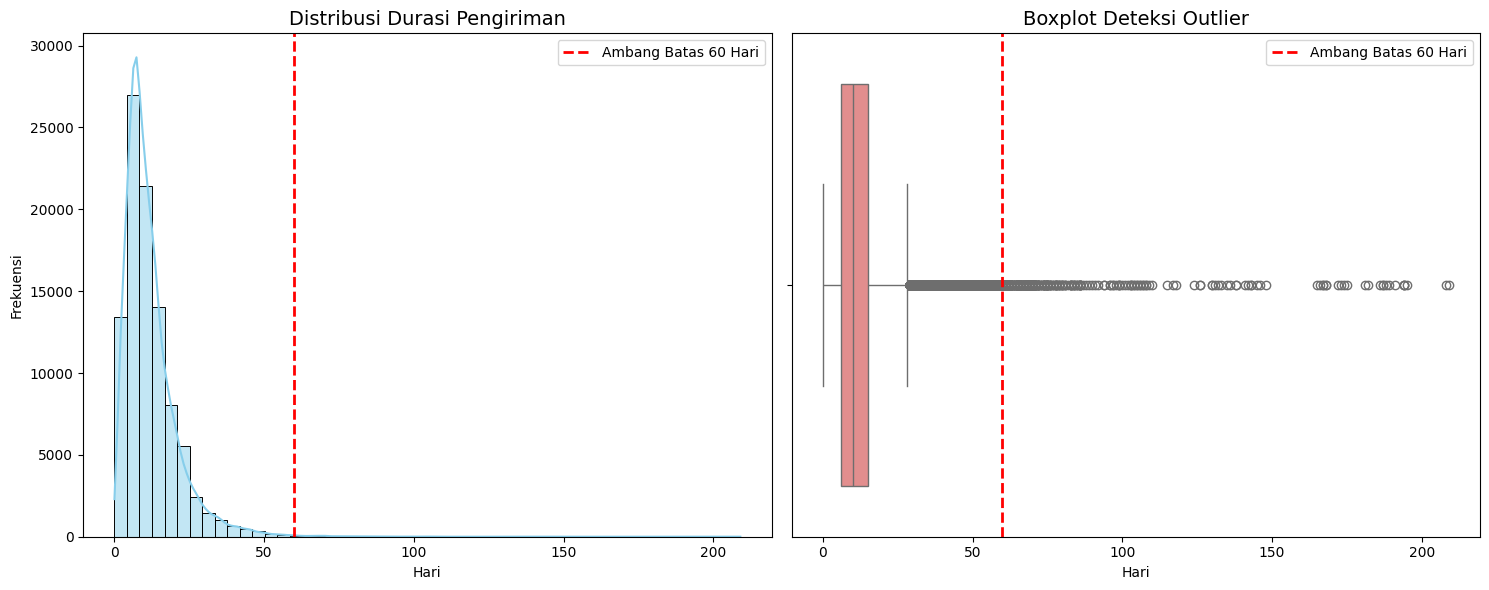

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur area plot: 1 baris, 2 kolom
plt.figure(figsize=(15, 6))

# --- Plot 1: Histogram (Melihat Sebaran & Kepadatan Data) ---
plt.subplot(1, 2, 1)
sns.histplot(df_featured['delivery_time'], bins=50, kde=True, color='skyblue')
plt.axvline(x=60, color='red', linestyle='--', linewidth=2, label='Ambang Batas 60 Hari')
plt.title('Distribusi Durasi Pengiriman', fontsize=14)
plt.xlabel('Hari')
plt.ylabel('Frekuensi')
plt.legend()

# --- Plot 2: Boxplot (Melihat Titik-Titik Outlier secara Spesifik) ---
plt.subplot(1, 2, 2)
sns.boxplot(x=df_featured['delivery_time'], color='lightcoral')
plt.axvline(x=60, color='red', linestyle='--', linewidth=2, label='Ambang Batas 60 Hari')
plt.title('Boxplot Deteksi Outlier', fontsize=14)
plt.xlabel('Hari')
plt.legend()

plt.tight_layout()
plt.show()

#### Analisis Batas Outlier:

Penentuan batas 60 hari didasarkan pada asumsi operasional logistik Olist Brasil. Berdasarkan data, pengiriman di atas 60 hari merupakan kejadian langka (anomali) yang kemungkinan besar disebabkan oleh faktor eksternal yang tidak dapat dikendalikan model (seperti kehilangan barang atau bencana).

Dengan membuang 303 baris data ekstrem ini, kita menjaga integritas statistik agar model Machine Learning dapat fokus mempelajari pola pengiriman reguler, sehingga meningkatkan akurasi prediksi untuk 99% transaksi lainnya.

#### 4.3: Handling Outlier
Menghapus data pengiriman yang tidak logis atau terlalu ekstrem

In [6]:
def perform_final_cleaning(df):
    """
    Menghapus outliers pengiriman (>60 hari) dan membersihkan sisa missing values.
    """
    df_clean = df.copy()
    initial_rows = len(df_clean)
    
    # 1. Handling Outliers (Logika: 0 - 60 hari)
    df_clean = df_clean[(df_clean['delivery_time'] >= 0) & (df_clean['delivery_time'] <= 60)]
    rows_after_outlier = len(df_clean)
    
    # 2. Drop sisa Missing Values (seperti order_approved_at yang kosong sedikit tadi)
    df_clean = df_clean.dropna()
    rows_final = len(df_clean)
    
    # --- Laporan Final ---
    print("="*40)
    print(f"{'LAPORAN PEMBERSIHAN AKHIR':^40}")
    print("="*40)
    print(f"Jumlah Baris Awal      : {initial_rows}")
    print(f"Baris Dibuang (Outlier): {initial_rows - rows_after_outlier}")
    print(f"Baris Dibuang (Missing): {rows_after_outlier - rows_final}")
    print("-" * 40)
    print(f"Jumlah Baris Final     : {rows_final}")
    print(f"Status Missing Values  : {df_clean.isnull().sum().sum()}")
    print(f"STATUS                 : {'SIAP EKSPOR' if df_clean.isnull().sum().sum() == 0 else 'CEK LAGI'}")
    print("="*40)
    
    return df_clean

# Eksekusi Final
df_final = perform_final_cleaning(df_featured)

       LAPORAN PEMBERSIHAN AKHIR        
Jumlah Baris Awal      : 96475
Baris Dibuang (Outlier): 288
Baris Dibuang (Missing): 15
----------------------------------------
Jumlah Baris Final     : 96172
Status Missing Values  : 0
STATUS                 : SIAP EKSPOR


### 5. Ekspor Data Final
Dataset telah melalui tahap penggabungan, konstruksi fitur (`delivery_time`, `is_late`), serta penanganan nilai anomali (*outliers*). Data final disimpan ke dalam folder `data/processed/` untuk digunakan secara konsisten pada tahap pemodelan Machine Learning di notebook berikutnya.

In [7]:
# Membuat folder jika belum ada
os.makedirs('../data/processed/', exist_ok=True)

# Simpan ke format pickle
df_final.to_pickle('../data/processed/df_final_logistics.pkl')

print("--- Data berhasil disimpan di folder processed! ---")

--- Data berhasil disimpan di folder processed! ---


### 6. Final Validation & Data Export
Tahap ini merupakan gerbang terakhir sebelum data masuk ke proses pemodelan. Dataset yang telah melalui proses *cleaning*, *merging*, *feature engineering*, dan *outlier handling* akan divalidasi kualitasnya.

**Poin Validasi Akhir:**
* **Integritas Baris:** Memastikan jumlah baris akhir tetap konsisten setelah filter pencilan (outliers).
* **Kualitas Fitur:** Memastikan fitur target (`is_late`) dan fitur pendukung (`delivery_time`) tidak memiliki nilai kosong (*null*).

Dataset final ini disimpan dalam format `.pkl` di folder `data/processed/` untuk menjaga tipe data (terutama kolom tanggal dan kategori) agar tetap konsisten saat dimuat di notebook berikutnya.

In [8]:
# Cek apakah file bisa dimuat ulang
df_check = pd.read_pickle('../data/processed/df_final_logistics.pkl')

print("--- Step 6: Verifikasi Berhasil ---")
print(f"Data yang tersimpan memiliki {df_check.shape[0]} baris dan {df_check.shape[1]} kolom.")

# Cek 5 baris pertama untuk memastikan data tidak korup saat di-load
display(df_check[['order_id', 'delivery_time', 'is_late']].head())

# Cek apakah ada kolom baru yang punya Null
print(df_final[['order_purchase_month', 'is_sp_district', 'is_late']].isnull().sum())

--- Step 6: Verifikasi Berhasil ---
Data yang tersimpan memiliki 96172 baris dan 21 kolom.


,order_id,delivery_time,is_late
13958,03caa2c082116e1d31e67e9ae3700499,18,0
69543,736e1922ae60d0d6a89247b851902527,11,0
23138,0812eb902a67711a1cb742b3cdaa65ae,18,0
29628,fefacc66af859508bf1a7934eab1e97f,20,1
3665,f5136e38d1a14a4dbd87dff67da82701,11,0


order_purchase_month    0
is_sp_district          0
is_late                 0
dtype: int64


#### **Kesimpulan: Dataset Siap untuk Fase Pemodelan**

Notebook 3 ini menjadi jembatan penting dari sekadar "melihat data" (EDA) menuju fase prediksi. Dengan selesainya tahap ini, kita telah berhasil mentransformasi dataset mentah Olist menjadi bahan baku berkualitas tinggi yang siap diproses secara teknis.

**Pencapaian Utama:**
- **Target Terdefinisi:** Kita telah memiliki kolom target yang jelas (`is_late`) untuk diprediksi.
- **Integritas Data:** Sampah berupa data pengiriman ekstrem (*outliers*) telah dibersihkan agar tidak mengganggu performa model.
- **Master Data:** Dataset final telah tersimpan secara aman dan terstandarisasi di folder `processed`.
  
Untuk memastikan bahwa fitur delivery_time dan is_late hanya digunakan sebagai target/analisis, dan fitur yang digunakan untuk prediksi nantinya adalah fitur yang sudah diketahui saat pesanan dibuat (mencegah data leakage).

**Langkah Selanjutnya:**
Kita akan berlanjut ke **Notebook 4 (Modeling)**. Di sana, kita akan melakukan langkah-langkah teknis penentuan performa model, mulai dari pembagian data (*Train-Test Split*), pengolahan variabel kategori (*Encoding*), hingga melatih algoritma Machine Learning untuk memprediksi risiko keterlambatan pengiriman secara akurat.

*Sampai jumpa di notebook berikutnya!*